In [1]:
import cospar as cs
import pandas as pd
import scipy
import numpy as np
import os
import scanpy as sc
from cospar.plotting import _utils as pl_util

%reload_ext autoreload
%autoreload 2

import pandas as pd
import torch
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
adata = sc.read_h5ad('../datasets/Human_CordBlood/adata_update.h5ad')
adata

AnnData object with n_obs × n_vars = 24885 × 3462
    obs: 'Timepoint', 'gfp_late', 'GFP', 'Tissue', 'Batch', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'S_score', 'G2M_score', 'phase', 'label_full', 'label_red', 'clones', 'time_label_full', 'time_label_red', 'Meta clones', 'leiden', 'transferred_labels', 'prediction_score_max', 'dpt_pseudotime', 'def_lab'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std', 'gene_removed'
    uns: 'Batch_colors', 'Timepoint_colors', 'def_lab_colors', 'diffmap_evals', 'final_lab_colors', 'hvg', 'iroot', 'label_full_colors', 'leiden', 'leiden_colors', 'neighbors', 'pca', 'phase_colors', 'pred_corr_colors', 'rank_genes_groups', 'transferred_labels_colors', 'umap'
    obsm: 'X_diffmap', 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'seurat'
    obsp: 'connectivities', 'distances'

In [4]:
adata.obs['meta_clones'] = adata.obs['Meta clones'].values
adata.obs['label_man'] = adata.obs['def_lab'].values
adata = adata[adata.obs['meta_clones'] != '-1.0', :]
adata.obs['Clone_ID'] = [name[6:] for name in adata.obs.clones.values]

/tmp/ipykernel_1980761/2535711007.py:4: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs['Clone_ID'] = [name[6:] for name in adata.obs.clones.values]


In [5]:
selected_fates = ["Late Erythroid", "Monocyte", "DC", "Mast cell"]

In [6]:
import os 
os.chdir('/ssd/users/mingzegao/clonaltrans/clonaltrans/')

path = '../trials/v1.2.0/checkpoints/CordBloodDynamicRates/1213_100718/model_last.pt'
model = torch.load(path, map_location='cpu')
device = torch.device('cpu')

import os 
os.chdir('/ssd/users/mingzegao/clonaltrans/')

In [7]:
cluster_names = np.array(['HSC/MPP 1', 'HSC/MPP 2', 'MEMP', 'Mast cell', 'Early Erythroid',
       'Mid Erythroid', 'Late Erythroid', 'NMP', 'Mono precur',
       'Monocyte', 'DC precursor', 'DC'])

In [8]:
gillespie_dir='./trials/v1.2.0/checkpoints/CordBloodDynamicGillespie/1216_150034/models/'

In [9]:
from clonaltrans.pl import compare_gt_pairwise

Init celltype: ['HSC/MPP 1'], processed Clone 0 with 92 trails
Init celltype: ['HSC/MPP 1'], processed Clone 1 with 0 trails
Init celltype: ['HSC/MPP 1'], processed Clone 2 with 1000 trails
Init celltype: ['HSC/MPP 1'], processed Clone 3 with 0 trails
Init celltype: ['HSC/MPP 1'], processed Clone 4 with 89 trails
Init celltype: ['HSC/MPP 1'], processed Clone 5 with 324 trails
Init celltype: ['HSC/MPP 1'], processed Clone 6 with 294 trails
Init celltype: ['HSC/MPP 1'], processed Clone 7 with 594 trails
Init celltype: ['HSC/MPP 1'], processed Clone 8 with 0 trails
Init celltype: ['HSC/MPP 1'], processed Clone 10 with 0 trails
Init celltype: ['HSC/MPP 1'], processed Clone BG with 141 trails
Descendents of HSC/MPP 1: ['DC', 'DC precursor', 'Early Erythroid', 'HSC/MPP 2', 'Late Erythroid', 'MEMP', 'Mast cell', 'Mid Erythroid', 'Mono precur', 'Monocyte', 'NMP']


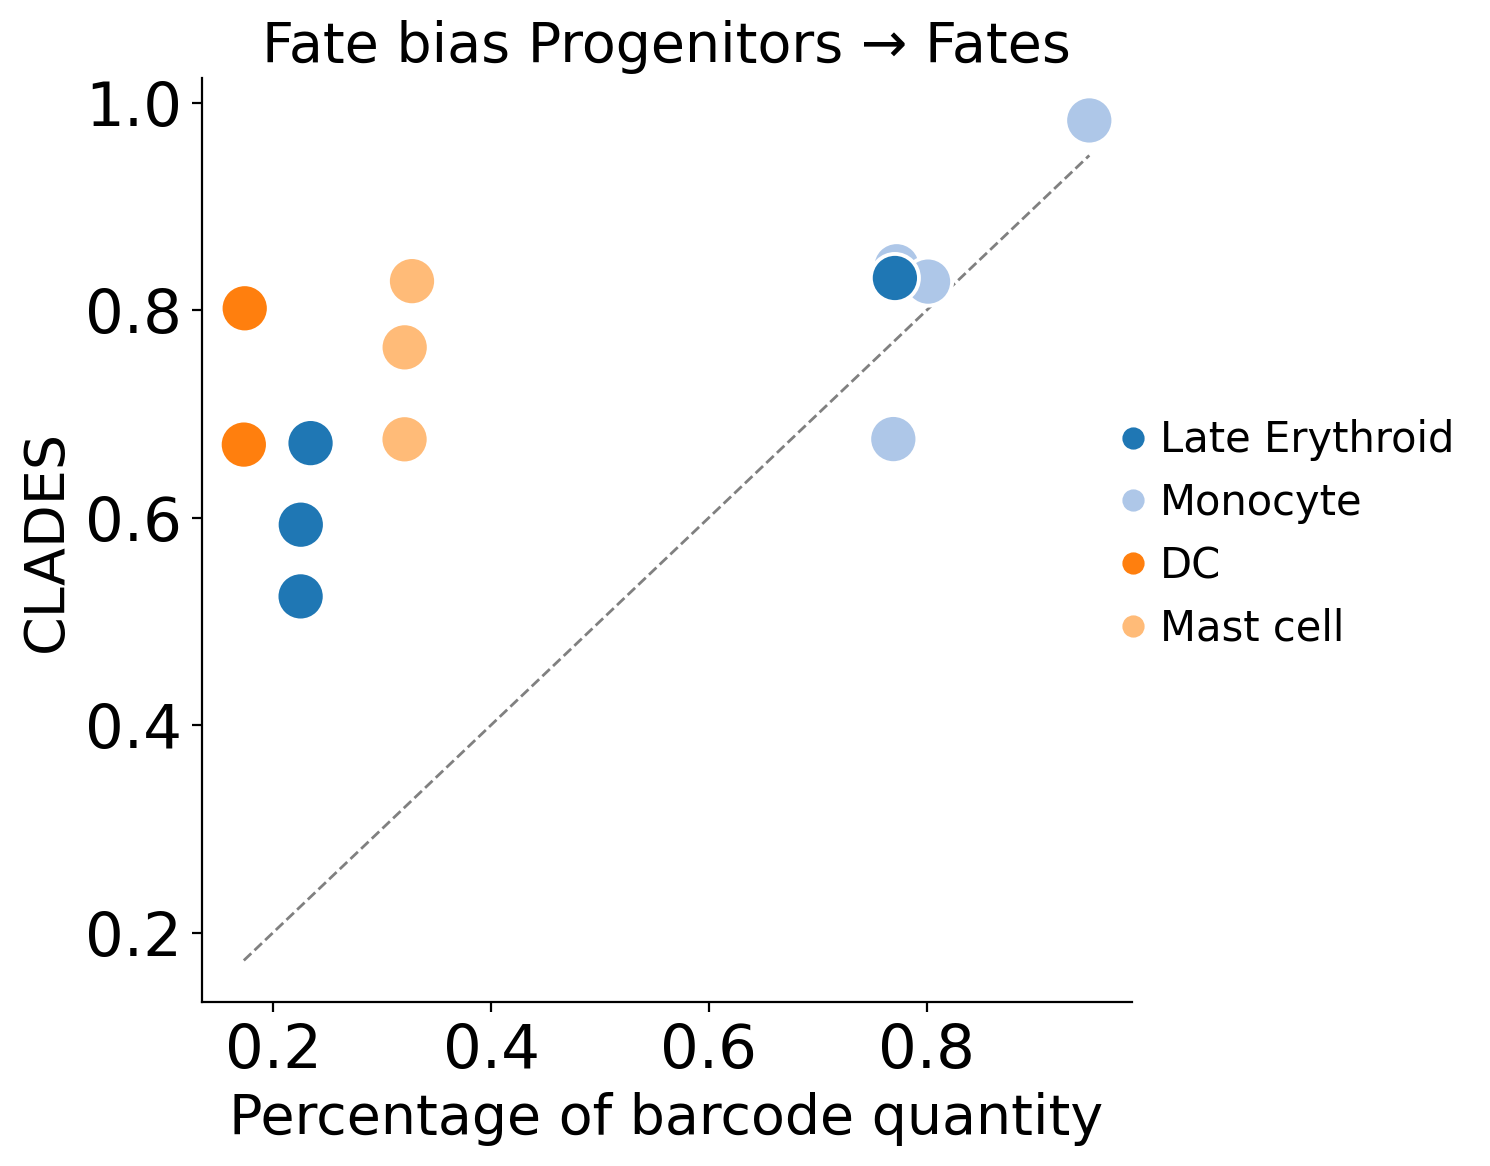

In [22]:
from clonaltrans.pl import compare_gt_all
compare_gt_all(
    adata, 
    model, 
    cluster_names,
    gillespie_dir,
    selected_fates,
    selected_fates,
    init_celltype=['HSC/MPP 1'],
    show_fate=True,
    save='bias_all_fate'
)

Init celltype: ['HSC/MPP 1'], processed Clone 0 with 92 trails
Init celltype: ['HSC/MPP 1'], processed Clone 1 with 0 trails
Init celltype: ['HSC/MPP 1'], processed Clone 2 with 1000 trails
Init celltype: ['HSC/MPP 1'], processed Clone 3 with 0 trails
Init celltype: ['HSC/MPP 1'], processed Clone 4 with 89 trails
Init celltype: ['HSC/MPP 1'], processed Clone 5 with 324 trails
Init celltype: ['HSC/MPP 1'], processed Clone 6 with 294 trails
Init celltype: ['HSC/MPP 1'], processed Clone 7 with 594 trails
Init celltype: ['HSC/MPP 1'], processed Clone 8 with 0 trails
Init celltype: ['HSC/MPP 1'], processed Clone 10 with 0 trails
Init celltype: ['HSC/MPP 1'], processed Clone BG with 141 trails
Descendents of HSC/MPP 1: ['DC', 'DC precursor', 'Early Erythroid', 'HSC/MPP 2', 'Late Erythroid', 'MEMP', 'Mast cell', 'Mid Erythroid', 'Mono precur', 'Monocyte', 'NMP']


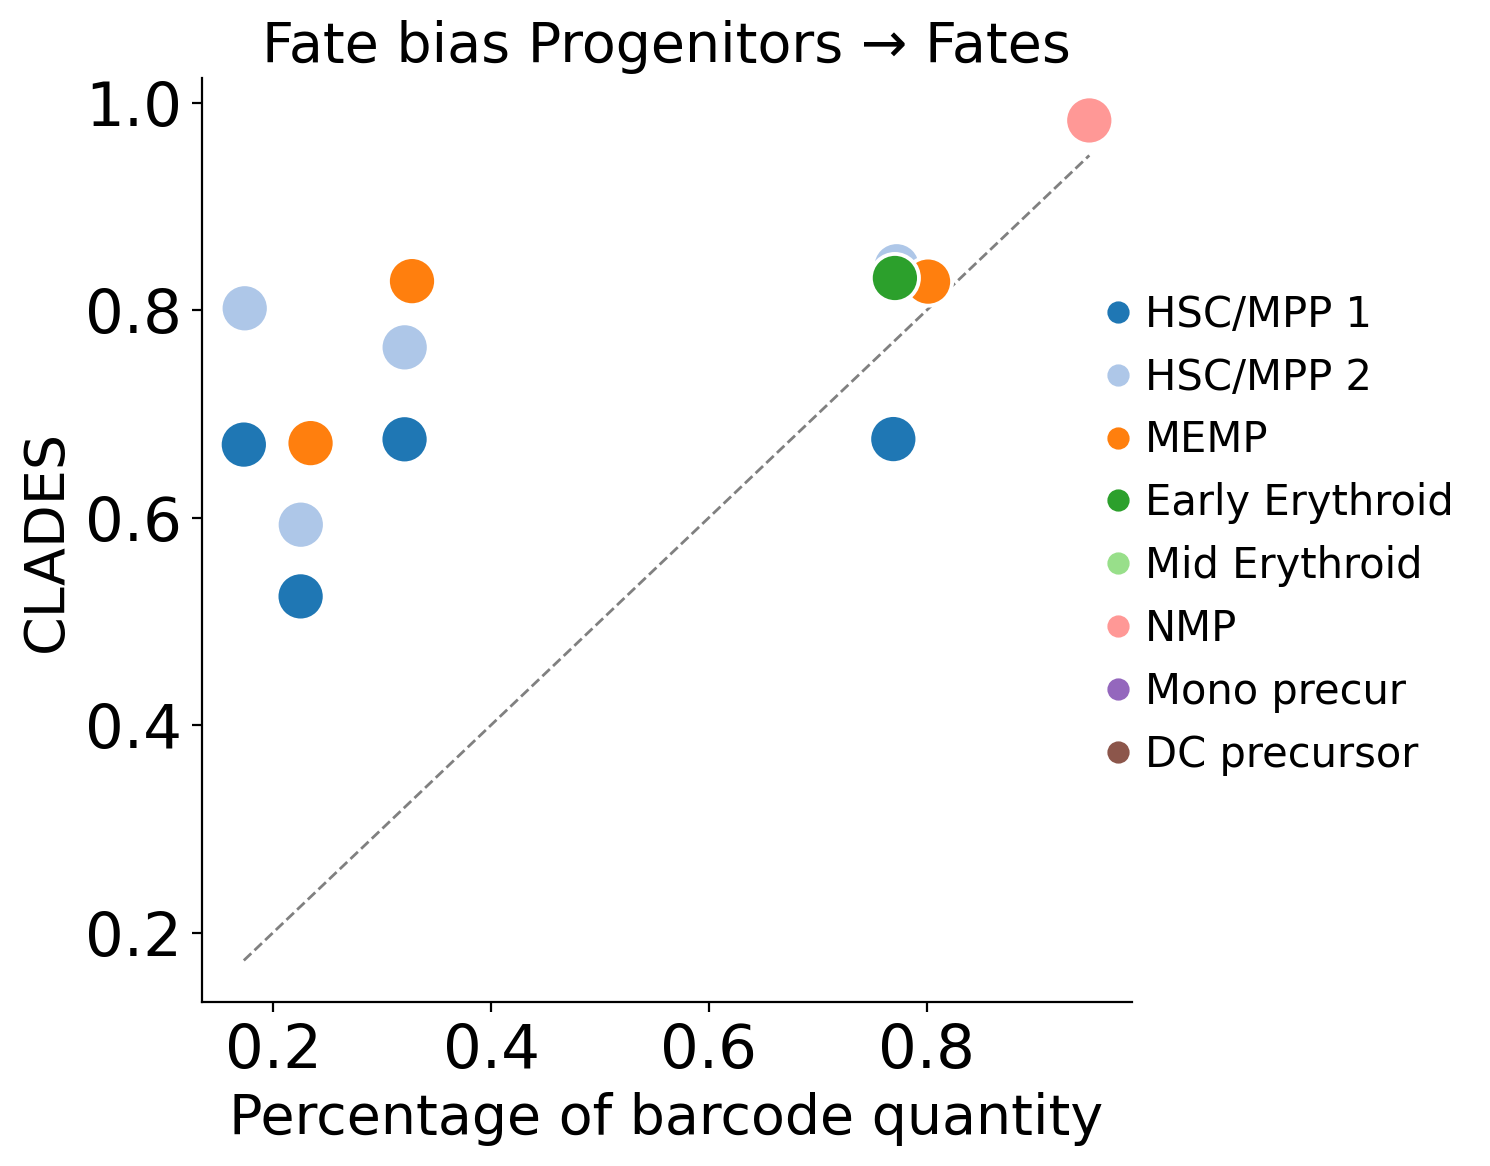

In [21]:
from clonaltrans.pl import compare_gt_all
compare_gt_all( 
    adata, 
    model, 
    cluster_names,
    gillespie_dir,
    selected_fates,
    selected_fates,
    init_celltype=['HSC/MPP 1'],
    show_fate=False,
    save='bias_all_prog'
)

Init celltype: ['HSC/MPP 1'], processed Clone 0 with 92 trails
Init celltype: ['HSC/MPP 1'], processed Clone 1 with 0 trails
Init celltype: ['HSC/MPP 1'], processed Clone 2 with 1000 trails
Init celltype: ['HSC/MPP 1'], processed Clone 3 with 0 trails
Init celltype: ['HSC/MPP 1'], processed Clone 4 with 89 trails
Init celltype: ['HSC/MPP 1'], processed Clone 5 with 324 trails
Init celltype: ['HSC/MPP 1'], processed Clone 6 with 294 trails
Init celltype: ['HSC/MPP 1'], processed Clone 7 with 594 trails
Init celltype: ['HSC/MPP 1'], processed Clone 8 with 0 trails
Init celltype: ['HSC/MPP 1'], processed Clone 10 with 0 trails
Init celltype: ['HSC/MPP 1'], processed Clone BG with 141 trails
[0.85928573 0.68128342 0.74290538 0.80701754 0.         0.8996139
 0.71230043]
[0.74468085 0.24528302 0.01754386 0.02083333 0.         0.20454545
 0.40753425]


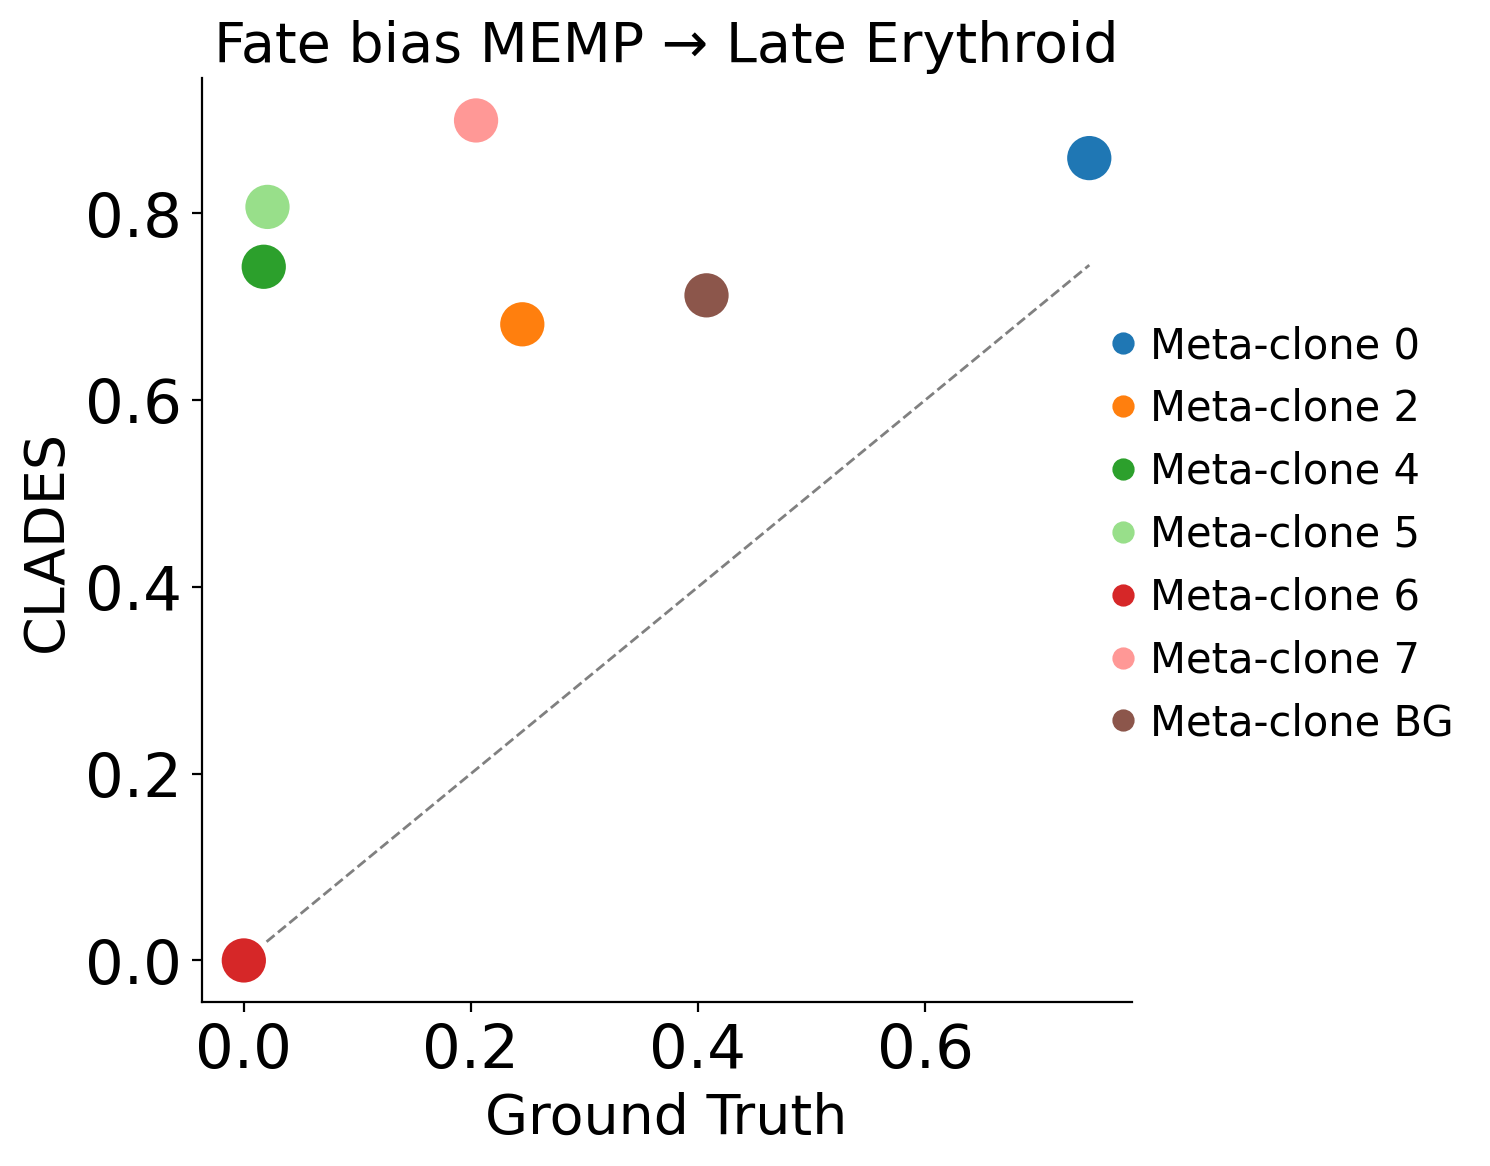

In [18]:
compare_gt_pairwise( 
    adata, 
    'MEMP', 
    'Late Erythroid', 
    model, 
    cluster_names,
    gillespie_dir, 
    selected_fates,
    init_celltype=['HSC/MPP 1'],
)

Init celltype: ['HSC/MPP 1'], processed Clone 0 with 92 trails


Init celltype: ['HSC/MPP 1'], processed Clone 1 with 0 trails
Init celltype: ['HSC/MPP 1'], processed Clone 2 with 1000 trails
Init celltype: ['HSC/MPP 1'], processed Clone 3 with 0 trails
Init celltype: ['HSC/MPP 1'], processed Clone 4 with 89 trails
Init celltype: ['HSC/MPP 1'], processed Clone 5 with 324 trails
Init celltype: ['HSC/MPP 1'], processed Clone 6 with 294 trails
Init celltype: ['HSC/MPP 1'], processed Clone 7 with 594 trails
Init celltype: ['HSC/MPP 1'], processed Clone 8 with 0 trails
Init celltype: ['HSC/MPP 1'], processed Clone 10 with 0 trails
Init celltype: ['HSC/MPP 1'], processed Clone BG with 141 trails
[0.91617685 0.69110653 0.85072671 0.88454564 0.71456354 0.89195911
 0.94667514]
[0.25531915 0.68181818 0.98275862 1.         1.         1.
 0.48595041]


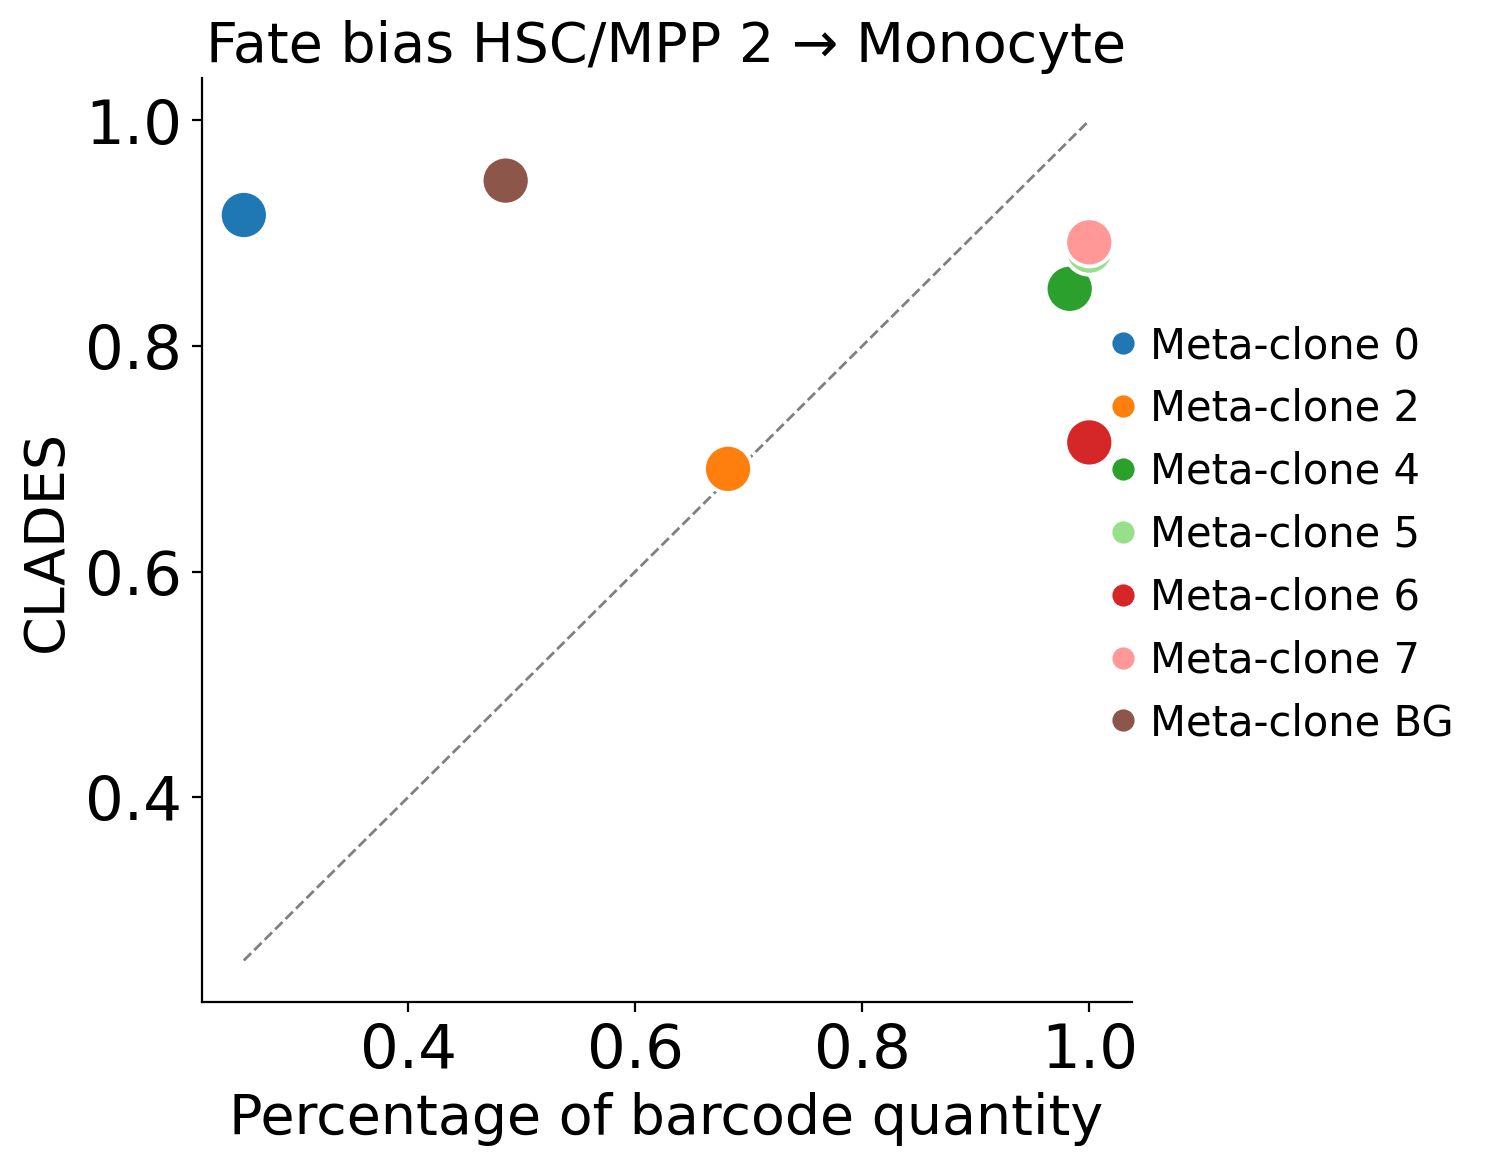

In [25]:
compare_gt_pairwise( 
    adata, 
    'HSC/MPP 2', 
    'Monocyte', 
    model, 
    cluster_names,
    gillespie_dir, 
    selected_fates,
    init_celltype=['HSC/MPP 1'],
    save='bias_hsc2_monocyte'
)

Init celltype: ['MEMP'], processed Clone 0 with 820 trails


Init celltype: ['MEMP'], processed Clone 1 with 1000 trails
Init celltype: ['MEMP'], processed Clone 2 with 0 trails
Init celltype: ['MEMP'], processed Clone 3 with 1000 trails
Init celltype: ['MEMP'], processed Clone 4 with 65 trails
Init celltype: ['MEMP'], processed Clone 5 with 0 trails
Init celltype: ['MEMP'], processed Clone 6 with 0 trails
Init celltype: ['MEMP'], processed Clone 7 with 0 trails
Init celltype: ['MEMP'], processed Clone 8 with 1000 trails
Init celltype: ['MEMP'], processed Clone 10 with 0 trails
Init celltype: ['MEMP'], processed Clone BG with 520 trails
[0.78398867 0.96       0.821      0.40156454 0.894      0.39790576]
[0.74468085 1.         0.8030303  0.01754386 0.28205128 0.40753425]


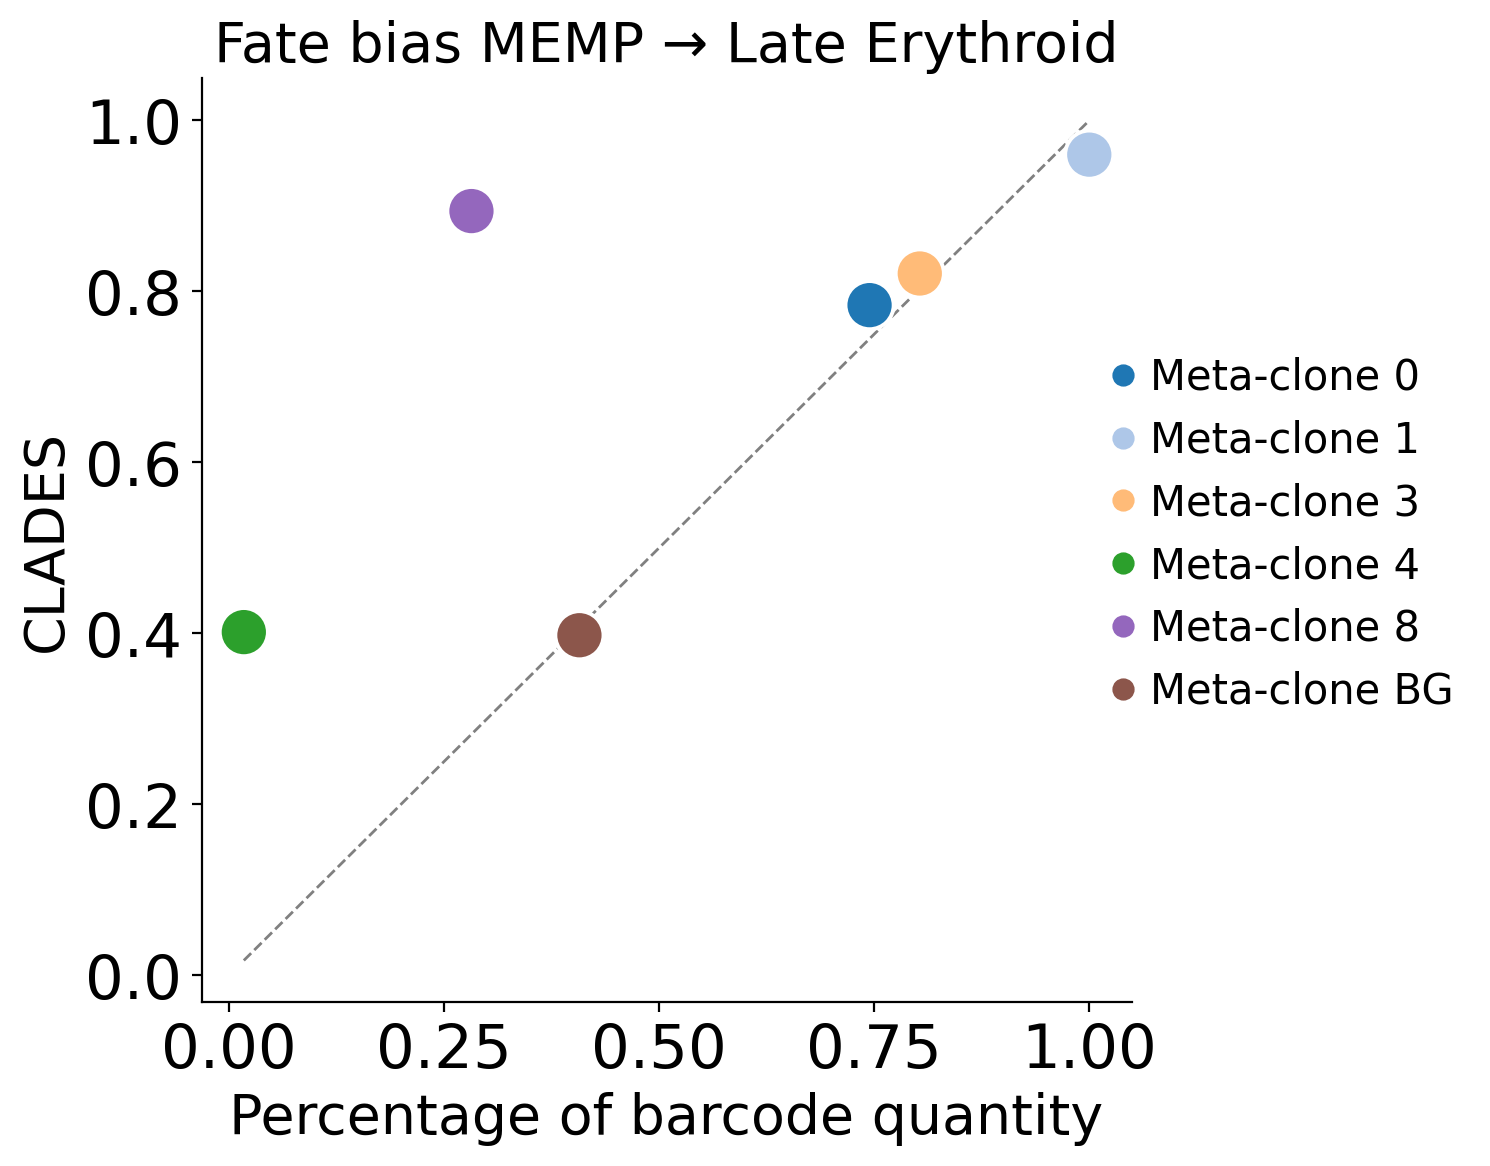

In [23]:
compare_gt_pairwise( 
    adata, 
    'MEMP', 
    'Late Erythroid', 
    model, 
    cluster_names,
    gillespie_dir, 
    selected_fates,
    init_celltype=['MEMP'],
    save='bias_memp_late_erythroid'
)

Init celltype: ['HSC/MPP 1'], processed Clone 0 with 92 trails
Init celltype: ['HSC/MPP 1'], processed Clone 1 with 0 trails
Init celltype: ['HSC/MPP 1'], processed Clone 2 with 1000 trails
Init celltype: ['HSC/MPP 1'], processed Clone 3 with 0 trails
Init celltype: ['HSC/MPP 1'], processed Clone 4 with 89 trails
Init celltype: ['HSC/MPP 1'], processed Clone 5 with 324 trails
Init celltype: ['HSC/MPP 1'], processed Clone 6 with 294 trails
Init celltype: ['HSC/MPP 1'], processed Clone 7 with 594 trails
Init celltype: ['HSC/MPP 1'], processed Clone 8 with 0 trails
Init celltype: ['HSC/MPP 1'], processed Clone 10 with 0 trails
Init celltype: ['HSC/MPP 1'], processed Clone BG with 141 trails
[0.68853337 0.59394668 0.34289969 0.80268726 0.85469441 0.63459055
 0.77514775]
[0.0106383  0.6969697  0.01724138 0.26530612 0.02173913 0.09090909
 0.10891089]


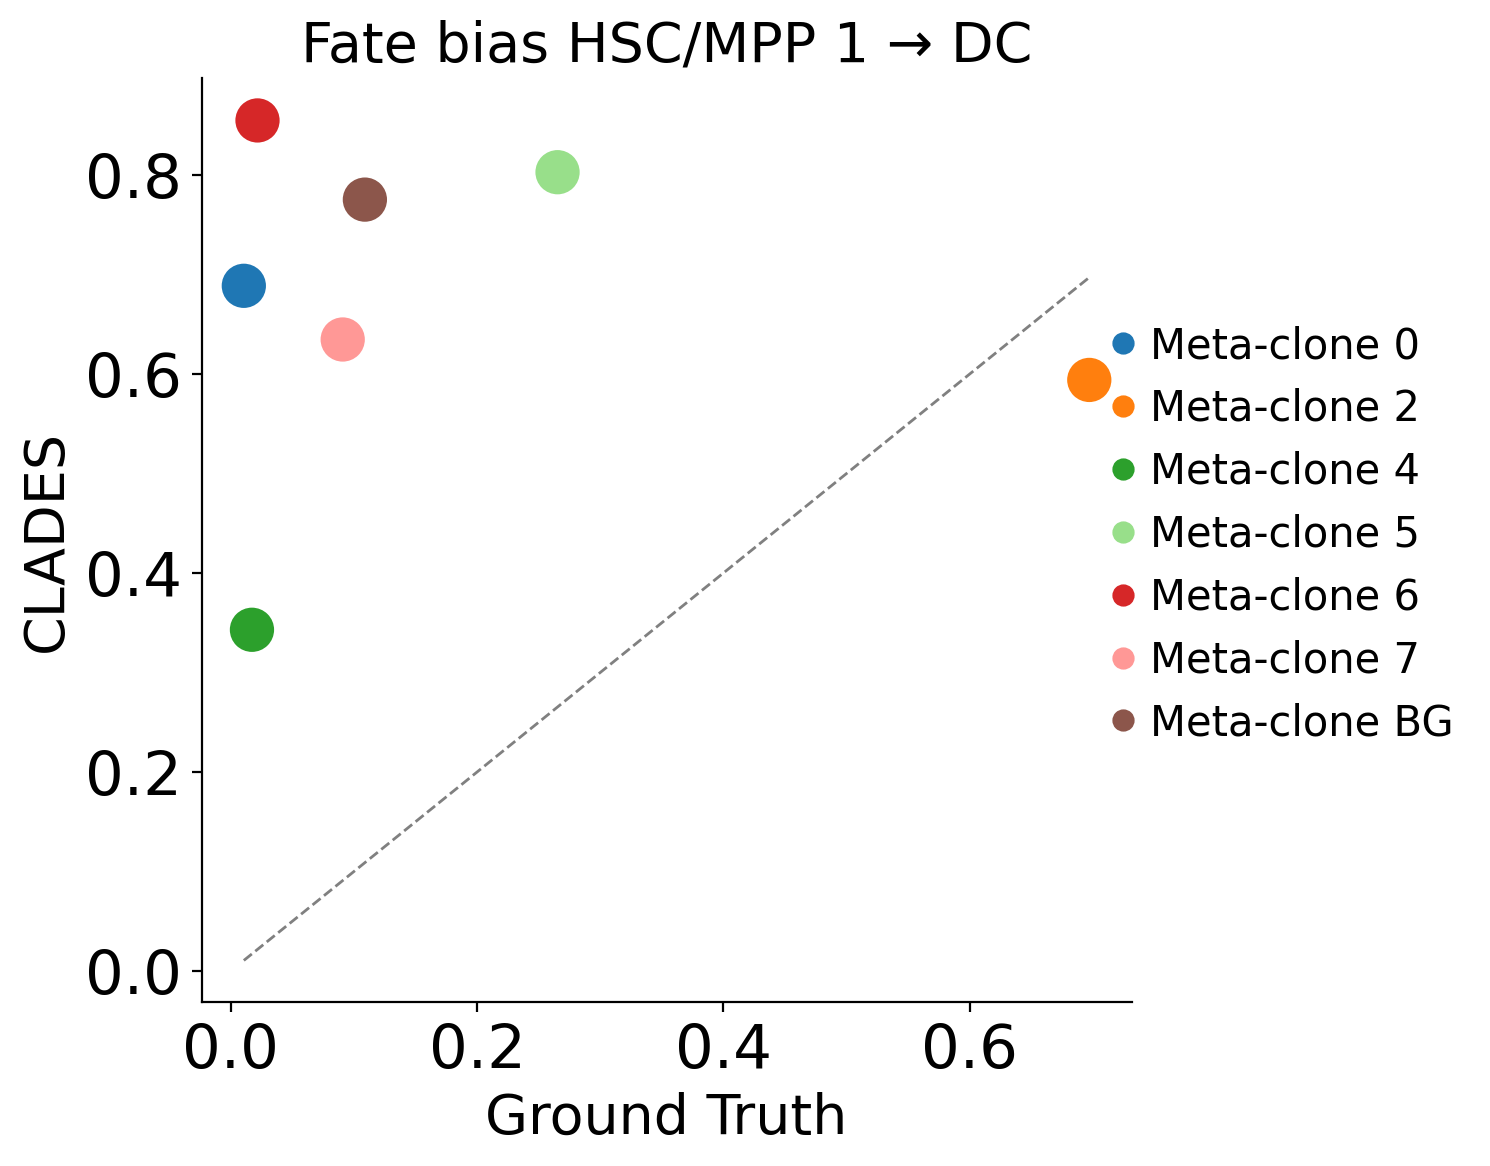

In [16]:
compare_gt_pairwise( 
    adata, 
    'HSC/MPP 1', 
    'DC', 
    model, 
    cluster_names,
    gillespie_dir, 
    selected_fates,
    init_celltype=['HSC/MPP 1'],
)

Init celltype: ['MEMP'], processed Clone 0 with 820 trails
Init celltype: ['MEMP'], processed Clone 1 with 1000 trails
Init celltype: ['MEMP'], processed Clone 2 with 0 trails
Init celltype: ['MEMP'], processed Clone 3 with 1000 trails
Init celltype: ['MEMP'], processed Clone 4 with 65 trails
Init celltype: ['MEMP'], processed Clone 5 with 0 trails
Init celltype: ['MEMP'], processed Clone 6 with 0 trails
Init celltype: ['MEMP'], processed Clone 7 with 0 trails
Init celltype: ['MEMP'], processed Clone 8 with 1000 trails
Init celltype: ['MEMP'], processed Clone 10 with 0 trails
Init celltype: ['MEMP'], processed Clone BG with 520 trails
Descendents of MEMP: ['Early Erythroid', 'Late Erythroid', 'Mast cell', 'Mid Erythroid', 'Mono precur', 'Monocyte']


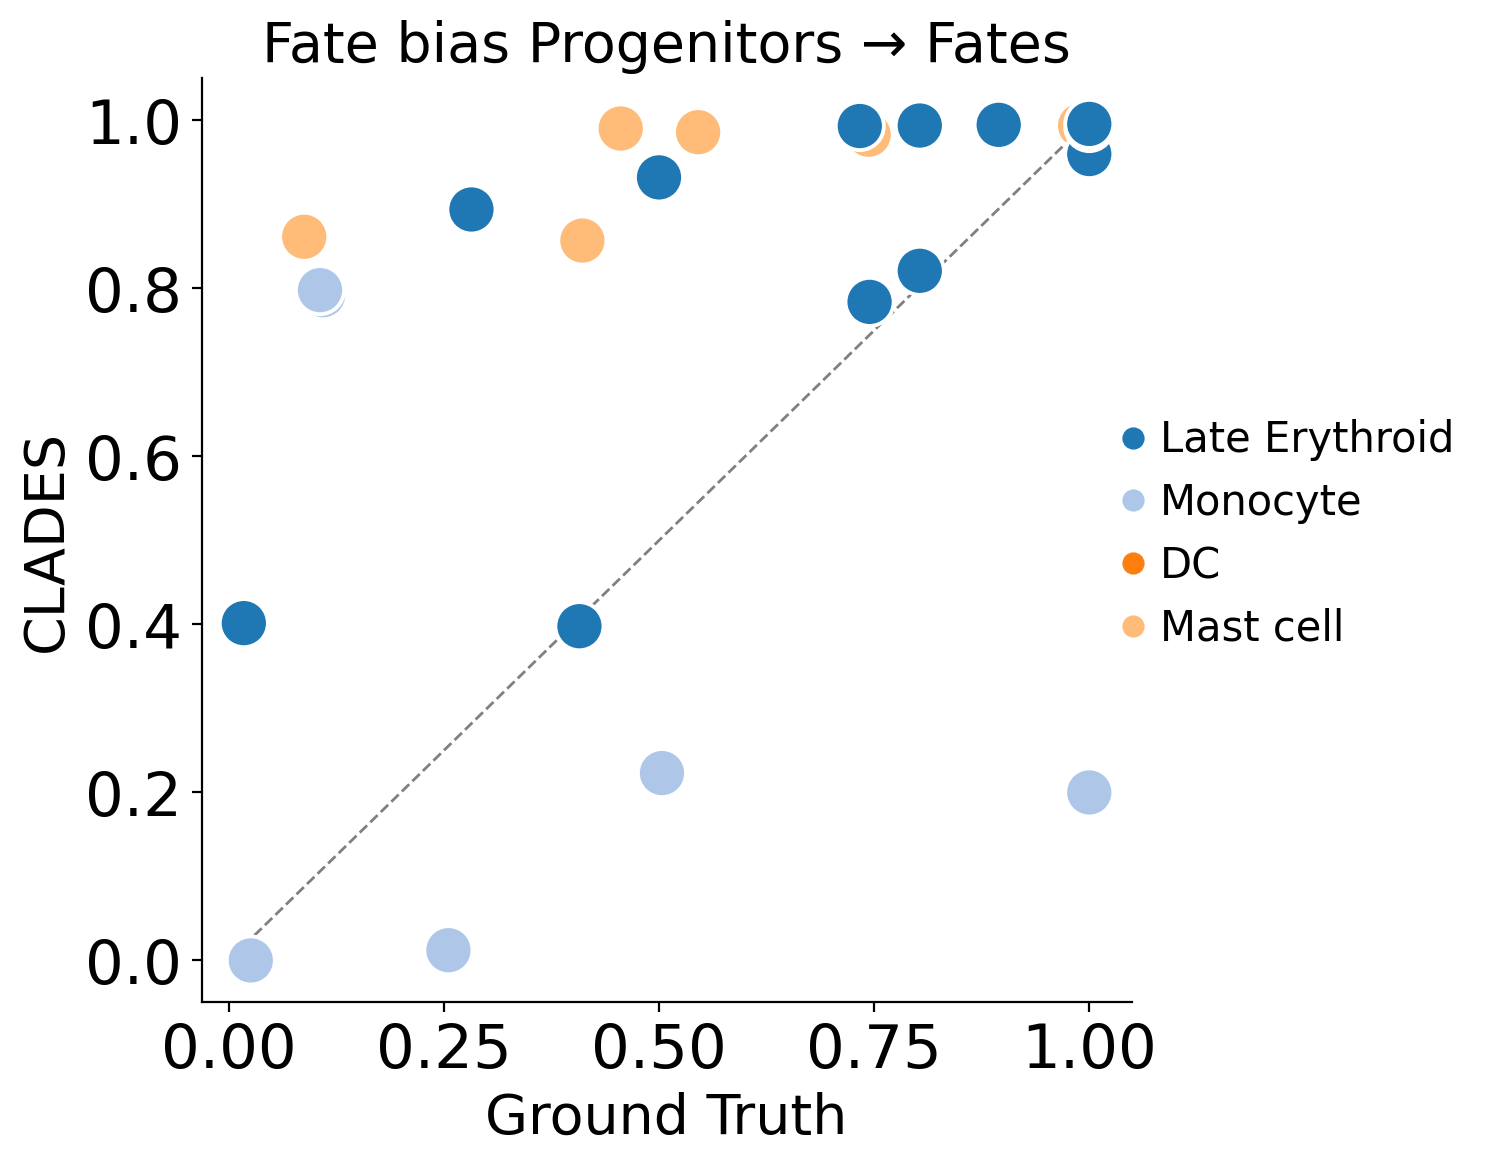

In [14]:
from clonaltrans.pl import compare_gt_all
compare_gt_all(
    adata, 
    model, 
    cluster_names,
    gillespie_dir,
    selected_fates,
    selected_fates,
    init_celltype=['MEMP'],
    show_fate=True
)

Init celltype: ['MEMP'], processed Clone 0 with 820 trails
Init celltype: ['MEMP'], processed Clone 1 with 1000 trails
Init celltype: ['MEMP'], processed Clone 2 with 0 trails
Init celltype: ['MEMP'], processed Clone 3 with 1000 trails
Init celltype: ['MEMP'], processed Clone 4 with 65 trails
Init celltype: ['MEMP'], processed Clone 5 with 0 trails
Init celltype: ['MEMP'], processed Clone 6 with 0 trails
Init celltype: ['MEMP'], processed Clone 7 with 0 trails
Init celltype: ['MEMP'], processed Clone 8 with 1000 trails
Init celltype: ['MEMP'], processed Clone 10 with 0 trails
Init celltype: ['MEMP'], processed Clone BG with 520 trails
Descendents of MEMP: ['Early Erythroid', 'Late Erythroid', 'Mast cell', 'Mid Erythroid', 'Mono precur', 'Monocyte']


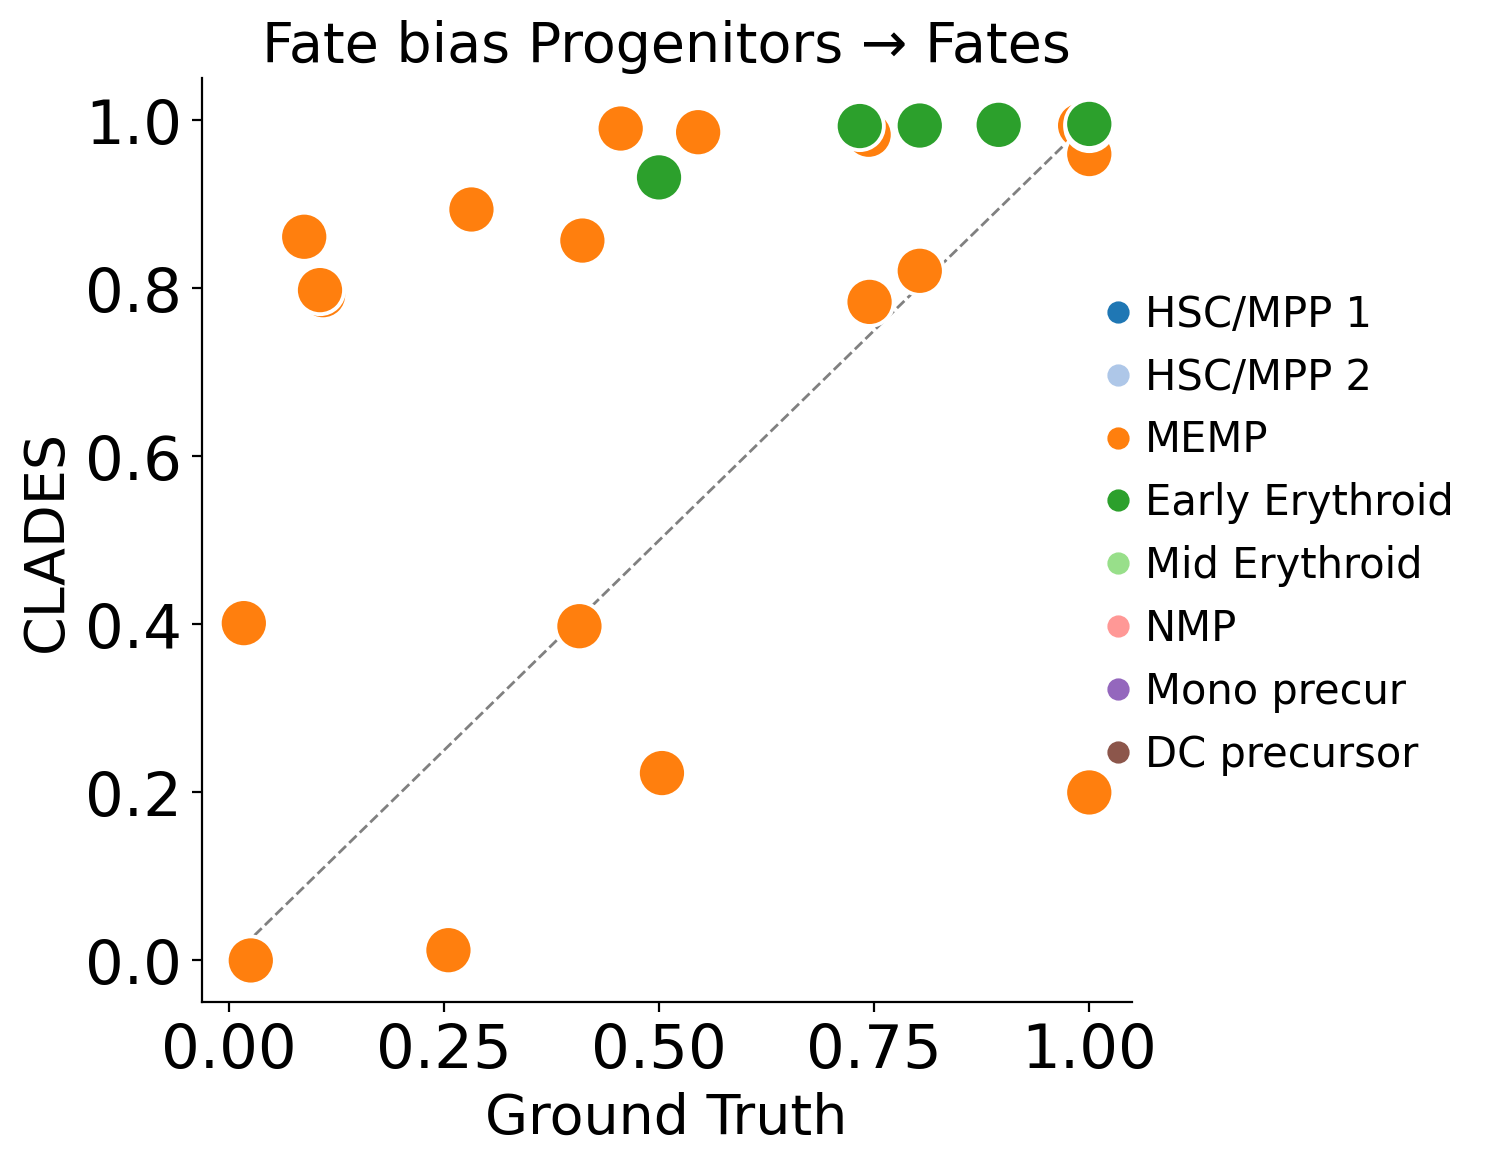

In [13]:
from clonaltrans.pl import compare_gt_all
compare_gt_all( 
    adata, 
    model, 
    cluster_names,
    gillespie_dir,
    selected_fates,
    selected_fates,
    init_celltype=['MEMP'],
    show_fate=False
)